# 04. Análisis exploratorio de perfiles de riesgo crediticio

En este notebook respondo las preguntas de negocio con el dataset limpio. Toda
comparación utiliza la tasa observada de `TARGET=1`. Hablaré de **dificultad de
pago observada** y no de probabilidad futura o decisión de aprobación.

## Carga del dataset analítico y KPIs generales

| Función | Qué hace | Para qué la utilizo |
|---|---|---|
| `pd.read_csv()` | Lee el CSV preparado en el notebook anterior | Conectar análisis y futuro dashboard |
| `.sum()` y `.mean()` | Calculan cantidades y promedios directamente | Construir tarjetas ejecutivas |
| `pd.DataFrame()` | Presenta el diccionario de KPIs en tabla | Hacer la lectura más clara |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `from pathlib import Path` | Importo manejo de rutas. |
| Imports de `matplotlib`, `pandas` y `seaborn` | Cargo herramientas de tablas y visualización. |
| `PROJECT_ROOT = ...` | Ubico la raíz del proyecto. |
| `CLEAN_PATH`, `IMAGES_PATH`, `REPORT_PATH` | Defino de dónde leo el dataset limpio y dónde guardaré resultados. |
| `.mkdir(...)` | Creo carpetas de imágenes y reportes si todavía no existen. |
| `clean_data = pd.read_csv(CLEAN_PATH)` | Leo la tabla que preparé en el notebook `03`. |
| `kpis = {...}` | Construyo un diccionario con los indicadores ejecutivos. |
| `len(clean_data)` | Cuento solicitudes totales. |
| `.sum()` sobre `TARGET` | Cuento solicitudes con dificultad, porque sus valores son `1`. |
| `.mean() * 100` sobre `TARGET` | Calculo la tasa porcentual de dificultad. |
| `.mean()` en montos, ratio y edad | Calculo valores promedio para contexto de cartera. |
| Variables terminadas en `_es` | Formateo números con punto de miles y coma decimal. |
| `kpi_table = pd.DataFrame(...)` | Armo una tabla presentable con nombre y valor de cada KPI. |
| `display(kpi_table)` | Muestro los KPIs en el notebook. |

In [1]:
# Importo Path para manejar rutas de lectura y escritura dentro del proyecto.
from pathlib import Path

# Importo librerías de tablas y visualización para realizar el EDA.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Detecto la raíz del proyecto, ya sea que ejecute desde ella o desde notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
# Defino la fuente limpia y los destinos de gráficos y reporte final.
CLEAN_PATH = PROJECT_ROOT / "data" / "clean" / "credit_risk_clean.csv"
IMAGES_PATH = PROJECT_ROOT / "images"
REPORT_PATH = PROJECT_ROOT / "reports" / "credit_risk_analysis_report.md"
# Creo las carpetas de resultados si no existen todavía.
IMAGES_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Cargo el CSV analítico que preparé en el notebook anterior.
clean_data = pd.read_csv(CLEAN_PATH)
# Calculo los indicadores principales que quiero mostrar en la vista ejecutiva.
kpis = {
    "total_solicitudes": len(clean_data),                              # Cantidad analizada.
    "clientes_en_dificultad": int(clean_data["TARGET"].sum()),          # Casos TARGET=1.
    "tasa_dificultad_pct": clean_data["TARGET"].mean() * 100,          # Porcentaje TARGET=1.
    "ingreso_promedio": clean_data["AMT_INCOME_TOTAL"].mean(),         # Ingreso medio.
    "credito_promedio": clean_data["AMT_CREDIT"].mean(),               # Crédito medio.
    "ratio_credito_ingreso_promedio": clean_data["CREDIT_INCOME_RATIO"].mean(), # Exposición media.
    "edad_promedio": clean_data["AGE"].mean(),                         # Edad media.
}
# Formateo los KPIs con notación española para presentarlos en tablas y reportes.
total_es = f'{kpis["total_solicitudes"]:,}'.replace(",", ".")
dificultad_es = f'{kpis["clientes_en_dificultad"]:,}'.replace(",", ".")
tasa_es = f'{kpis["tasa_dificultad_pct"]:.2f}'.replace(".", ",")
ingreso_es = f'{kpis["ingreso_promedio"]:,.2f}'.replace(",", "X").replace(".", ",").replace("X", ".")
credito_es = f'{kpis["credito_promedio"]:,.2f}'.replace(",", "X").replace(".", ",").replace("X", ".")
ratio_es = f'{kpis["ratio_credito_ingreso_promedio"]:.2f}'.replace(".", ",")
edad_es = f'{kpis["edad_promedio"]:.1f}'.replace(".", ",")

# Organizo nombres y resultados formateados en una tabla ejecutiva.
kpi_table = pd.DataFrame(
    {
        "KPI": [
            "Total solicitudes",
            "Clientes con dificultad",
            "Tasa de dificultad",
            "Ingreso promedio",
            "Crédito promedio",
            "Ratio crédito/ingreso promedio",
            "Edad promedio",
        ],
        "Valor": [
            total_es, dificultad_es, f"{tasa_es}%", ingreso_es, credito_es,
            f"{ratio_es}x", f"{edad_es} años",
        ],
    }
)
# Muestro la tabla de indicadores generales en el notebook.
display(kpi_table)

,KPI,Valor
0,Total solicitudes,307.511
1,Clientes con dificultad,24.825
2,Tasa de dificultad,"8,07%"
3,Ingreso promedio,"168.797,92"
4,Crédito promedio,"599.026,00"
5,Ratio crédito/ingreso promedio,"3,96x"
6,Edad promedio,"43,9 años"


## 1. Ingreso y ratio crédito/ingreso

Primero reviso dos hipótesis: si menor ingreso coincide con mayor dificultad y
si solicitar un crédito muchas veces superior al ingreso aumenta la tasa.

| Función | Qué hace | Para qué sirve |
|---|---|---|
| `.groupby()` | Agrupa solicitudes por segmento | Comparar grupos con la misma regla |
| `.agg()` | Calcula cantidad, dificultades y promedio | Crear la tabla de tasas |
| `sns.barplot()` | Grafica tasas agrupadas | Visualizar diferencias sin mostrar personas |
| `.savefig()` | Exporta la gráfica | Incluirla en README y Power BI como referencia |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `income_order` y `ratio_order` | Fijo el orden lógico en que quiero ver las categorías en las gráficas. |
| `income_summary = (...)` | Inicio el resumen por segmento de ingreso. |
| `.groupby(...)["TARGET"]` | Agrupo solicitudes y selecciono el resultado de pago. |
| `.agg(count, sum, mean)` | Calculo volumen, cantidad con dificultad y tasa por grupo. |
| `.reset_index()` | Devuelvo el segmento a una columna visible. |
| `ratio_summary = (...)` | Repito el mismo resumen para el ratio crédito/ingreso. |
| Columnas `tasa_dificultad_pct` | Convierto las tasas decimales a porcentajes redondeados. |
| `.sort_values(...)` | Ordeno las tablas de mayor a menor tasa observada. |
| `display(...)` | Muestro las dos tablas antes de graficar. |
| `fig, axes = plt.subplots(...)` | Creo dos espacios gráficos en una misma figura. |
| Primer `sns.barplot(...)` | Grafico tasa por segmento de ingreso. |
| Segundo `sns.barplot(...)` | Grafico tasa por segmento de ratio crédito/ingreso. |
| `.set(...)` y `.tick_params(...)` | Coloco títulos, ejes y giro etiquetas para legibilidad. |
| `plt.tight_layout()` | Ajusto los espacios internos. |
| `plt.savefig(...)` | Exporto la imagen del análisis financiero. |
| `plt.show()` | Visualizo el resultado en el notebook. |

,INCOME_SEGMENT,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
3,Medio bajo,53182,4537,0.085311,8.53
2,Medio alto,82213,6902,0.083953,8.40
1,Bajo,100578,8443,0.083945,8.39
0,Alto,71538,4943,0.069096,6.91


,CREDIT_INCOME_SEGMENT,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
0,2x-4x,113540,10073,0.088718,8.87
1,4x-6x,62854,5112,0.081331,8.13
3,Hasta 2x,76411,5676,0.074282,7.43
2,6x-10x,44868,3291,0.073348,7.33
4,Más de 10x,9838,673,0.068408,6.84


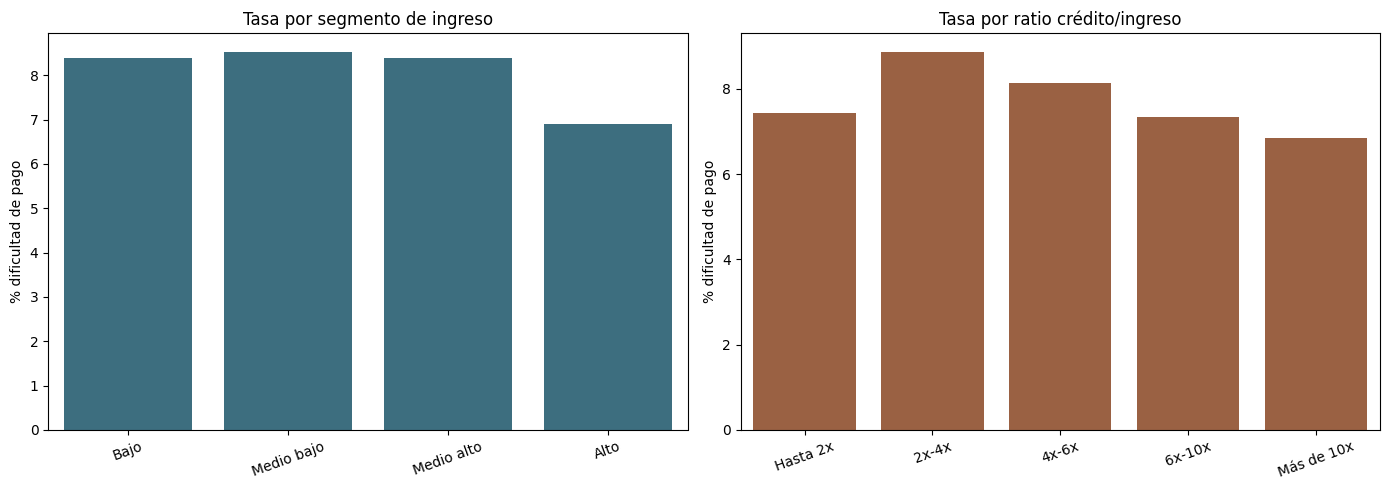

In [2]:
# Establezco órdenes lógicos para que los gráficos no dependan del orden de la tasa.
income_order = ["Bajo", "Medio bajo", "Medio alto", "Alto"]
ratio_order = ["Hasta 2x", "2x-4x", "4x-6x", "6x-10x", "Más de 10x"]
# Agrupo por segmento de ingreso para contar solicitudes, dificultades y tasa histórica.
income_summary = (
    clean_data.groupby("INCOME_SEGMENT", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Repito la agregación para los rangos del ratio crédito/ingreso.
ratio_summary = (
    clean_data.groupby("CREDIT_INCOME_SEGMENT", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Convierto tasas decimales a porcentajes con dos cifras para mostrarlas.
income_summary["tasa_dificultad_pct"] = (income_summary["tasa_dificultad"] * 100).round(2)
ratio_summary["tasa_dificultad_pct"] = (ratio_summary["tasa_dificultad"] * 100).round(2)
# Ordeno las tablas de mayor a menor tasa para identificar los segmentos destacados.
income_summary = income_summary.sort_values("tasa_dificultad", ascending=False)
ratio_summary = ratio_summary.sort_values("tasa_dificultad", ascending=False)
# Presento las tablas numéricas antes de interpretar las gráficas.
display(income_summary)
display(ratio_summary)

# Creo una figura con dos gráficos: ingreso y ratio crédito/ingreso.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Visualizo la tasa de dificultad en cada segmento de ingreso.
sns.barplot(data=income_summary, x="INCOME_SEGMENT", y="tasa_dificultad_pct", order=income_order, ax=axes[0], color="#32748A")
axes[0].set(title="Tasa por segmento de ingreso", xlabel="", ylabel="% dificultad de pago")
axes[0].tick_params(axis="x", rotation=20)
# Visualizo la tasa según la relación entre crédito e ingreso.
sns.barplot(data=ratio_summary, x="CREDIT_INCOME_SEGMENT", y="tasa_dificultad_pct", order=ratio_order, ax=axes[1], color="#A85D35")
axes[1].set(title="Tasa por ratio crédito/ingreso", xlabel="", ylabel="% dificultad de pago")
axes[1].tick_params(axis="x", rotation=20)
# Ajusto espacios, guardo la imagen para el repositorio y la muestro.
plt.tight_layout()
plt.savefig(IMAGES_PATH / "financial_segments_default_rate.png", dpi=160)
plt.show()

### Qué concluyo

El segmento de ingreso alto muestra una tasa menor (**6,91%**) que los demás,
que están entre **8,39% y 8,53%**. Sin embargo, el ratio crédito/ingreso no
presenta una subida lineal: la tasa más alta está en `2x-4x` (**8,87%**) y no
en el rango de mayor ratio. Por eso usaré este indicador para describir
exposición financiera, no para afirmar por sí solo quién tiene mayor riesgo.

## 2. Edad y ocupación

Analizo diferencias de tasa por grupo de edad y por ocupación. En ocupación
aplico un filtro mínimo de 1.000 solicitudes: una tasa alta en un grupo muy
pequeño podría inducirme a una conclusión inestable.

| Función o parámetro | Qué hace | Razón |
|---|---|---|
| Filtro `>= 1000` | Excluye ocupaciones pequeñas del ranking | Reducir conclusiones basadas en muy pocos casos |
| `.head(10)` | Conserva las diez tasas mayores | Facilitar lectura del gráfico |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `age_order = [...]` | Defino el orden natural de los grupos de edad. |
| `age_summary = (...)` | Agrupo por edad y calculo volumen, dificultades y tasa. |
| `occupation_summary = (...)` | Agrupo por ocupación usando las mismas métricas. |
| Columnas `tasa_dificultad_pct` | Transformo las tasas a porcentaje para presentarlas. |
| `.sort_values(...)` en edad | Ordeno la tabla para localizar la tasa más alta. |
| Filtro `total_solicitudes >= 1000` | Evito destacar ocupaciones con muy poco volumen. |
| `display(...)` | Presento las tablas utilizadas para interpretar el patrón. |
| `plt.subplots(...)` | Creo dos gráficos comparables. |
| Primer `sns.barplot(...)` | Dibujo la tasa por grupos de edad. |
| `top_occupations = ...head(10)...` | Selecciono diez ocupaciones de mayor tasa y las ordeno para graficarlas. |
| Segundo `sns.barplot(...)` | Dibujo el ranking de ocupaciones. |
| `.set(...)`, `tight_layout`, `savefig`, `show` | Etiqueto, ajusto, guardo y muestro la figura final. |

,AGE_GROUP,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
5,Hasta 25,14289,1731,0.121142,12.11
0,26-35,74218,7857,0.105864,10.59
1,36-45,83953,6975,0.083082,8.31
2,46-55,69837,4873,0.069777,6.98
3,56-65,58901,3172,0.053853,5.39
4,65+,6313,217,0.034374,3.44


,OCCUPATION_TYPE,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
9,Low-skill Laborers,2093,359,0.171524,17.15
4,Drivers,18603,2107,0.113261,11.33
18,Waiters/barmen staff,1348,152,0.112760,11.28
17,Security staff,6721,722,0.107424,10.74
8,Laborers,55186,5838,0.105788,10.58
2,Cooking staff,5946,621,0.104440,10.44
15,Sales staff,32102,3092,0.096318,9.63
1,Cleaning staff,4653,447,0.096067,9.61
16,Secretaries,1305,92,0.070498,7.05
11,Medicine staff,8537,572,0.067002,6.70


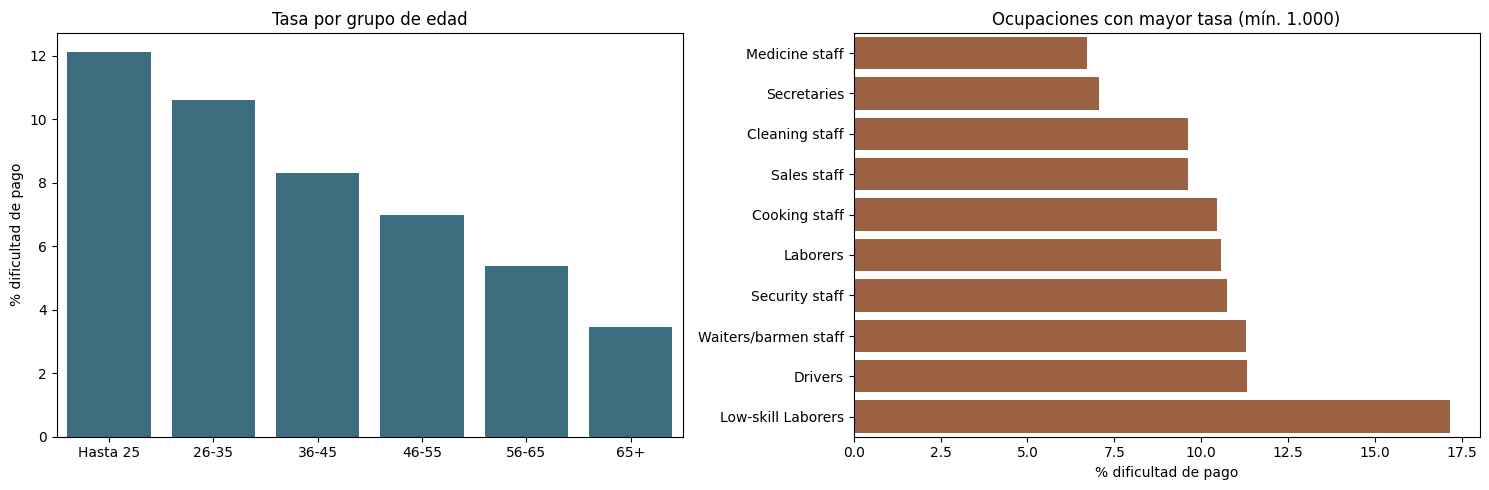

In [3]:
# Defino el orden cronológico para visualizar los rangos de edad.
age_order = ["Hasta 25", "26-35", "36-45", "46-55", "56-65", "65+"]
# Calculo cantidad y tasa de dificultad histórica por grupo de edad.
age_summary = (
    clean_data.groupby("AGE_GROUP", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Calculo el mismo resumen agrupando ahora por ocupación reportada.
occupation_summary = (
    clean_data.groupby("OCCUPATION_TYPE", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Transformo las tasas de ambas tablas a porcentaje legible.
age_summary["tasa_dificultad_pct"] = (age_summary["tasa_dificultad"] * 100).round(2)
occupation_summary["tasa_dificultad_pct"] = (occupation_summary["tasa_dificultad"] * 100).round(2)
# Ordeno edades de mayor a menor tasa para identificar el grupo destacado.
age_summary = age_summary.sort_values("tasa_dificultad", ascending=False)
# Conservo solo ocupaciones con volumen suficiente y las ordeno por tasa.
occupation_summary = (
    occupation_summary[occupation_summary["total_solicitudes"] >= 1000]
    .sort_values("tasa_dificultad", ascending=False)
)
# Muestro las tablas que respaldan mi interpretación.
display(age_summary)
display(occupation_summary.head(10))

# Inicio la figura comparativa de edad y ocupación.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Grafico la tasa observada por edad respetando el orden cronológico.
sns.barplot(data=age_summary, x="AGE_GROUP", y="tasa_dificultad_pct", order=age_order, ax=axes[0], color="#32748A")
axes[0].set(title="Tasa por grupo de edad", xlabel="", ylabel="% dificultad de pago")
# Selecciono las diez ocupaciones principales y las ordeno para barras horizontales.
top_occupations = occupation_summary.head(10).sort_values("tasa_dificultad_pct")
# Grafico el ranking de ocupaciones con mayor tasa observada.
sns.barplot(data=top_occupations, x="tasa_dificultad_pct", y="OCCUPATION_TYPE", ax=axes[1], color="#A85D35")
axes[1].set(title="Ocupaciones con mayor tasa (mín. 1.000)", xlabel="% dificultad de pago", ylabel="")
# Ajusto, exporto y muestro la figura generada.
plt.tight_layout()
plt.savefig(IMAGES_PATH / "demographic_segments_default_rate.png", dpi=160)
plt.show()

### Qué concluyo

Observo una diferencia marcada por edad: el grupo hasta 25 años alcanza
**12,11%**, mientras el grupo de 65+ se ubica en **3,44%**. Entre las
ocupaciones con al menos 1.000 solicitudes, `Low-skill Laborers` presenta
**17,15%**. Son señales para comprender la cartera y formular preguntas, no
atributos que deban utilizarse aisladamente para decidir un crédito.

## 3. Educación, vivienda y perfil analítico

Finalmente reviso variables de contexto y la segmentación financiera construida.
La comparación del perfil es especialmente importante: si las tasas resultan
muy similares, debo reconocer que la regla no discrimina dificultad de pago.

| Función | Qué hace | Uso |
|---|---|---|
| `.groupby()` + `.agg()` | Resume cantidad y tasa por categoría | Comparación consistente |
| `.sort_values()` | Ordena categorías por tasa | Ver primero los grupos con tasa mayor |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `education_summary = (...)` | Agrupo por nivel educativo y calculo sus métricas de dificultad. |
| `realty_summary = (...)` | Agrupo por tenencia de vivienda. |
| `profile_summary = (...)` | Agrupo por el perfil financiero descriptivo creado previamente. |
| `for summary in [...]` | Aplico exactamente el mismo tratamiento a las tres tablas. |
| `summary["tasa_dificultad_pct"] = ...` | Paso la tasa a porcentaje redondeado. |
| `summary.sort_values(..., inplace=True)` | Ordeno cada tabla de mayor a menor tasa. |
| `display(...)` | Muestro resultados para educación, vivienda y perfil. |
| `fig, axes = plt.subplots(...)` | Preparo dos gráficos en una figura. |
| `education_plot = ...sort_values(...)` | Ordeno educación para que la barra horizontal sea fácil de leer. |
| Primer `sns.barplot(...)` | Visualizo la diferencia por educación. |
| `profile_plot = ... != "Sin información"` | Retiro la categoría sin dato del gráfico de perfiles. |
| Segundo `sns.barplot(...)` | Visualizo las tasas por perfil financiero. |
| `.set(...)`, `tight_layout`, `savefig`, `show` | Etiqueto, acomodo, exporto y enseño la figura. |

,NAME_EDUCATION_TYPE,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
3,Lower secondary,3816,417,0.109277,10.93
4,Secondary / secondary special,218391,19524,0.089399,8.94
2,Incomplete higher,10277,872,0.084850,8.48
1,Higher education,74863,4009,0.053551,5.36
0,Academic degree,164,3,0.018293,1.83


,FLAG_OWN_REALTY,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
0,N,94199,7842,0.083249,8.32
1,Y,213312,16983,0.079616,7.96


,ANALYTICAL_PROFILE,total_solicitudes,clientes_en_dificultad,tasa_dificultad,tasa_dificultad_pct
0,Exposición financiera intermedia,114598,9330,0.081415,8.14
1,Mayor exposición financiera,52128,4225,0.081050,8.11
2,Menor exposición financiera,140773,11270,0.080058,8.01
3,Sin información,12,0,0.000000,0.00


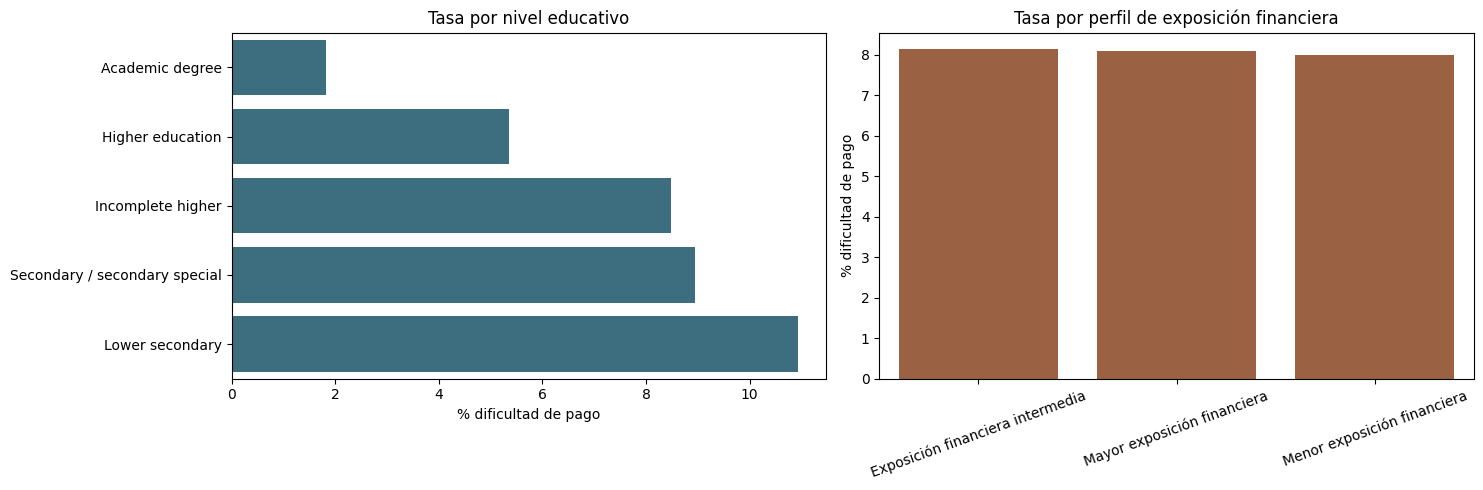

In [4]:
# Construyo una tabla de tasa de dificultad por nivel educativo.
education_summary = (
    clean_data.groupby("NAME_EDUCATION_TYPE", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Construyo una tabla equivalente según tenencia de vivienda.
realty_summary = (
    clean_data.groupby("FLAG_OWN_REALTY", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Construyo otra tabla para evaluar la segmentación financiera creada.
profile_summary = (
    clean_data.groupby("ANALYTICAL_PROFILE", observed=True)["TARGET"]
    .agg(total_solicitudes="count", clientes_en_dificultad="sum", tasa_dificultad="mean")
    .reset_index()
)
# Recorro las tres tablas para convertir tasas a porcentajes y ordenarlas.
for summary in [education_summary, realty_summary, profile_summary]:
    # Creo una columna porcentual que sea fácil de leer en tablas y gráficos.
    summary["tasa_dificultad_pct"] = (summary["tasa_dificultad"] * 100).round(2)
    # Dejo al inicio la categoría con mayor tasa observada.
    summary.sort_values("tasa_dificultad", ascending=False, inplace=True)
# Presento los tres resultados agregados para interpretación.
display(education_summary)
display(realty_summary)
display(profile_summary)

# Creo la figura de educación y perfil de exposición financiera.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Ordeno las categorías educativas para graficarlas horizontalmente.
education_plot = education_summary.sort_values("tasa_dificultad_pct")
# Grafico la tasa de dificultad por nivel educativo.
sns.barplot(data=education_plot, x="tasa_dificultad_pct", y="NAME_EDUCATION_TYPE", ax=axes[0], color="#32748A")
axes[0].set(title="Tasa por nivel educativo", xlabel="% dificultad de pago", ylabel="")
# Excluyo perfiles sin información para concentrar la comparación financiera.
profile_plot = profile_summary[profile_summary["ANALYTICAL_PROFILE"] != "Sin información"]
# Grafico la tasa observada por perfil descriptivo.
sns.barplot(data=profile_plot, x="ANALYTICAL_PROFILE", y="tasa_dificultad_pct", ax=axes[1], color="#A85D35")
axes[1].set(title="Tasa por perfil de exposición financiera", xlabel="", ylabel="% dificultad de pago")
axes[1].tick_params(axis="x", rotation=20)
# Ajusto la presentación, guardo el archivo y muestro la figura.
plt.tight_layout()
plt.savefig(IMAGES_PATH / "education_and_exposure_profile.png", dpi=160)
plt.show()

### Qué concluyo

`Lower secondary` registra **10,93%** de dificultad, frente a **5,36%** en
`Higher education`. La vivienda propia presenta una diferencia pequeña
(**7,96%** con propiedad frente a **8,32%** sin ella). Además, los tres perfiles
financieros construidos tienen tasas muy cercanas, alrededor de 8%; esa regla
sirve para describir exposición, pero no para priorizar incumplimiento de forma
convincente.

## 4. Exportación del reporte de conclusiones

| Función | Qué hace | Propósito |
|---|---|---|
| `.iloc[0]` | Toma el segmento con tasa más alta de una tabla ordenada | Resumir hallazgos calculados |
| `Path.write_text()` | Guarda el texto del reporte | Mantener un entregable reproducible |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `top_age`, `top_occupation`, `top_income`, `top_ratio` | Tomo la primera fila de cada tabla ya ordenada: el segmento con mayor tasa. |
| Variables terminadas en `_rate_es` | Formateo las tasas con coma decimal para el reporte en español. |
| `report = f'''...'''` | Escribo una plantilla de reporte e inserto KPIs y hallazgos calculados, no números manuales. |
| Sección `Alcance` del texto | Dejo visible que el análisis no es modelaje ni decisión automática. |
| Sección `KPIs Generales` | Inserto las métricas globales calculadas en la primera celda. |
| Sección `Hallazgos` | Inserto los segmentos de mayor tasa identificados en las tablas. |
| Secciones `Uso para Power BI` y `Limitaciones` | Documento cómo interpretar responsablemente el análisis. |
| `REPORT_PATH.write_text(..., encoding="utf-8")` | Guardo el reporte Markdown respetando caracteres en español. |
| `print(...)` | Confirmo la ruta del reporte generado. |

In [5]:
# Tomo el primer registro de cada tabla ordenada: corresponde a la mayor tasa observada.
top_age = age_summary.iloc[0]
top_occupation = occupation_summary.iloc[0]
top_income = income_summary.iloc[0]
top_ratio = ratio_summary.iloc[0]
# Formateo las tasas destacadas con coma decimal para escribir el reporte en español.
top_income_rate_es = f'{top_income["tasa_dificultad_pct"]:.2f}'.replace(".", ",")
top_ratio_rate_es = f'{top_ratio["tasa_dificultad_pct"]:.2f}'.replace(".", ",")
top_age_rate_es = f'{top_age["tasa_dificultad_pct"]:.2f}'.replace(".", ",")
top_occupation_rate_es = f'{top_occupation["tasa_dificultad_pct"]:.2f}'.replace(".", ",")

# Creo el texto del reporte insertando automáticamente los resultados calculados.
report = f'''# Reporte de Análisis de Riesgo Crediticio

## Alcance

Este reporte describe patrones históricos en solicitudes de Home Credit. No se
entrenó ningún modelo, no se genera scoring individual y los segmentos no
constituyen reglas de aprobación o rechazo.

## KPIs Generales

| Indicador | Resultado |
|---|---:|
| Total de solicitudes | {total_es} |
| Solicitudes con dificultad de pago | {dificultad_es} |
| Tasa de dificultad de pago | {tasa_es}% |
| Ingreso promedio | {ingreso_es} |
| Crédito promedio | {credito_es} |
| Ratio crédito/ingreso promedio | {ratio_es}x |
| Edad promedio | {edad_es} años |

## Hallazgos

- El segmento de ingreso con mayor tasa observada es **{top_income["INCOME_SEGMENT"]}** con **{top_income_rate_es}%**.
- El rango de ratio crédito/ingreso con mayor tasa es **{top_ratio["CREDIT_INCOME_SEGMENT"]}** con **{top_ratio_rate_es}%**; el comportamiento no es monotónico.
- El grupo de edad con mayor tasa es **{top_age["AGE_GROUP"]}** con **{top_age_rate_es}%**.
- Considerando ocupaciones con al menos 1.000 solicitudes, **{top_occupation["OCCUPATION_TYPE"]}** muestra la tasa más alta: **{top_occupation_rate_es}%**.
- El perfil de exposición financiera creado no separa fuertemente la tasa de dificultad; debe mostrarse como descriptor de cartera, no como clasificación de riesgo.

## Uso para Power BI

El dashboard debe destacar tasa general, composición de cartera y comparaciones
por segmento. Las vistas sociodemográficas sirven para análisis agregado y
discusión de políticas responsables, nunca para automatizar decisiones.

## Limitaciones

- Se analiza únicamente `application_train.csv`, sin historiales adicionales.
- Las asociaciones observadas no prueban causalidad.
- El dataset proviene de una competencia pública y no representa una política
  crediticia productiva de una entidad específica.
'''
# Escribo el reporte en Markdown conservando acentos y caracteres en español.
REPORT_PATH.write_text(report, encoding="utf-8")
# Confirmo la ubicación del entregable generado.
print(f"Reporte generado: {REPORT_PATH.relative_to(PROJECT_ROOT)}")

Reporte generado: reports/credit_risk_analysis_report.md


## Cierre del análisis

Mi conclusión principal es que la lectura de riesgo crediticio requiere contexto:
la tasa general es 8,07%, pero cambia visiblemente en algunos segmentos de edad,
ocupación y educación. En contraste, la segmentación financiera sencilla que
propuse no basta para ordenar el incumplimiento; documentar esa limitación hace
el análisis más responsable.

El siguiente entregable es el dashboard que construiré posteriormente siguiendo
`powerbi/README.md`.